# Foundations of Complex Analysis for Spec- tral Theory (Matrix and Operator View- point)

## Resolvent expansion and coefficients

We stay with your running example
$$
  A=\begin{pmatrix}0&1\\0&0\end{pmatrix},
$$
$z_0=1$

In [ ]:
import numpy as np

# Define the matrix A
A = np.array([[0., 1.],
              [0., 0.]])

I = np.eye(2)
z0 = 1.0

# Precompute (z0 I - A)^{-1}
R0 = np.linalg.inv(z0 * I - A)

def resolvent(z):
    """Exact resolvent (zI - A)^{-1}"""
    return np.linalg.inv(z * I - A)

# Compute first few Taylor coefficients
coeffs = []
for k in range(5):
    Ck = (-1)**k * np.linalg.matrix_power(R0, k+1)
    coeffs.append(Ck)

# Print coefficients
for k, Ck in enumerate(coeffs):
    print(f"\nCoefficient C_{k}:")
    print(Ck)



Coefficient C_0:
[[1. 1.]
 [0. 1.]]

Coefficient C_1:
[[-1. -2.]
 [-0. -1.]]

Coefficient C_2:
[[1. 3.]
 [0. 1.]]

Coefficient C_3:
[[-1. -4.]
 [-0. -1.]]

Coefficient C_4:
[[1. 5.]
 [0. 1.]]


Interpretation:

- The diagonal entries alternate like the scalar expansion of $1/z$ around $z=1$.
- The upper-right entry grows linearly with $k$:
$$
(C_k)_{12}=-(k+1)(-1)^k,
$$
which directly reflects the Jordan block / nilpotent part of
$A$.
- This growth is invisible from eigenvalues alone.

### Verifying the expansion numerically
We can check that the truncated series approximates the resolvent:


In [ ]:
def resolvent_series(z, N=5):
    S = np.zeros((2,2))
    for k in range(N):
        S += coeffs[k] * (z - z0)**k
    return S

z_test = 1.3

print("Exact resolvent:")
print(resolvent(z_test))

print("\nSeries approximation:")
print(resolvent_series(z_test, N=5))


Exact resolvent:
[[0.76923077 0.59171598]
 [0.         0.76923077]]

Series approximation:
[[0.7711 0.6025]
 [0.     0.7711]]


As long as
$$
|z-1|<1
$$
the approximation improves rapidly with $N$.

The growing off-diagonal Taylor coefficients numerically expose the non-normal (Jordan) structure that the spectrum alone cannot see.

## Operator-valued contour integral

Example that computes the operator-valued contour integral for a $2 \times 2$ nilpotent matrix $A$ and visualizes the contour in the complex plane. This reproduces the Riesz projection numerically.

Numerical Riesz projection P:
[[1.00000000e+00+7.73111858e-19j 5.30092447e-17+6.92872198e-17j]
 [0.00000000e+00+0.00000000e+00j 1.00000000e+00+7.73111858e-19j]]


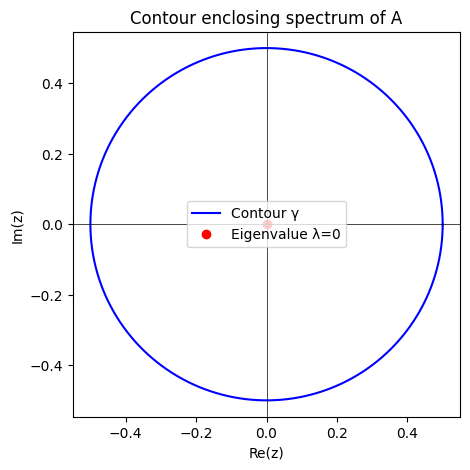

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the matrix A
A = np.array([[0.0, 1.0],
              [0.0, 0.0]])

# Define contour gamma(t) = r*exp(it)
r = 0.5                  # radius (encloses the eigenvalue 0)
N = 2000                 # number of discretization points
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
z = r * np.exp(1j*theta)
dz = 1j * z * (2*np.pi/N)  # dz = gamma'(t)*dt

# Initialize the integral
integral = np.zeros((2, 2), dtype=complex)

# Sum the resolvent times dz along the contour
for zi, dzi in zip(z, dz):
    resolvent = np.linalg.inv(zi*np.eye(2) - A)
    integral += resolvent * dzi

# Divide by 2*pi*i to get the Riesz projection
P = integral / (2j * np.pi)

print("Numerical Riesz projection P:")
print(P)

# Plot the contour and eigenvalue
plt.figure(figsize=(5,5))
plt.plot(z.real, z.imag, 'b-', label='Contour γ')
plt.plot(0, 0, 'ro', label='Eigenvalue λ=0')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Contour enclosing spectrum of A')
plt.axis('equal')
plt.legend()
plt.show()


Example that not only computes the Riesz projection, but also plots the norm of the resolvent along the contour, so you can see how it “blows up” near the eigenvalue at 0.


Numerical Riesz projection P:
[[1.00000000e+00+7.73111858e-19j 5.30092447e-17+6.92872198e-17j]
 [0.00000000e+00+0.00000000e+00j 1.00000000e+00+7.73111858e-19j]]


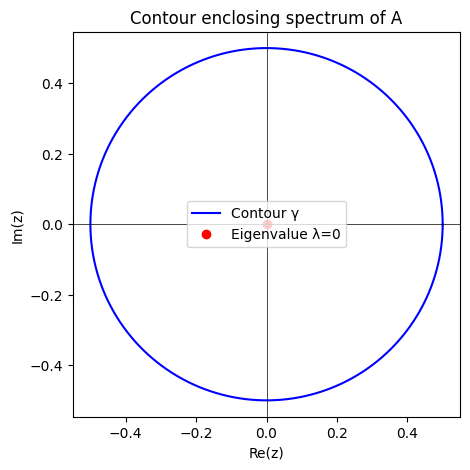

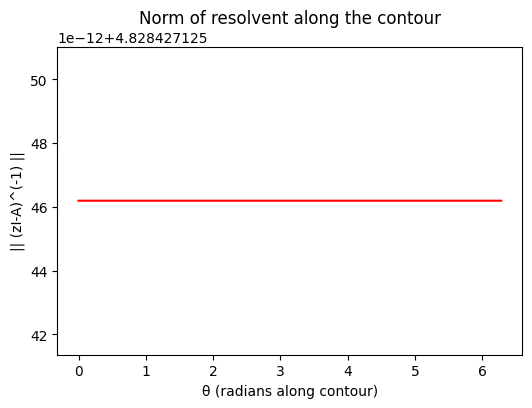

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the matrix A
A = np.array([[0.0, 1.0],
              [0.0, 0.0]])

# Contour gamma(t) = r * exp(i t)
r = 0.5                 # radius enclosing eigenvalue 0
N = 2000                # discretization points
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
z = r * np.exp(1j * theta)
dz = 1j * z * (2*np.pi / N)

# Initialize the integral
integral = np.zeros((2, 2), dtype=complex)

# Compute resolvent along the contour and store norms
resolvent_norms = np.zeros(N)
for idx, (zi, dzi) in enumerate(zip(z, dz)):
    R = np.linalg.inv(zi * np.eye(2) - A)
    integral += R * dzi
    resolvent_norms[idx] = np.linalg.norm(R, ord=2)  # operator 2-norm

# Compute Riesz projection
P = integral / (2j * np.pi)

print("Numerical Riesz projection P:")
print(P)

# Plot contour in complex plane
plt.figure(figsize=(5,5))
plt.plot(z.real, z.imag, 'b-', label='Contour γ')
plt.plot(0, 0, 'ro', label='Eigenvalue λ=0')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Contour enclosing spectrum of A')
plt.axis('equal')
plt.legend()
plt.show()

# Plot resolvent norm along the contour
plt.figure(figsize=(6,4))
plt.plot(theta, resolvent_norms, 'r-')
plt.xlabel('θ (radians along contour)')
plt.ylabel('|| (zI-A)^(-1) ||')
plt.title('Norm of resolvent along the contour')
plt.show()


We’ll use an off-center circular contour, i.e., a circle not centered on the eigenvalue, so the distance $|z|$ varies along the contour. This makes the entries of the resolvent vary in magnitude, producing a norm that changes along the contour, visually showing how contributions cancel around the eigenvalue.


Numerical Riesz projection P:
[[1.00000000e+00+1.55624064e-18j 5.07522104e-16+2.05558574e-16j]
 [0.00000000e+00+0.00000000e+00j 1.00000000e+00+1.55624064e-18j]]


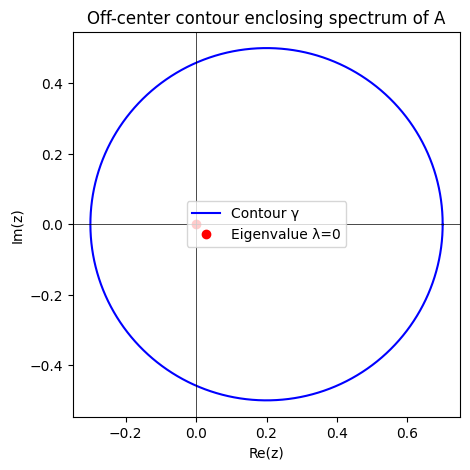

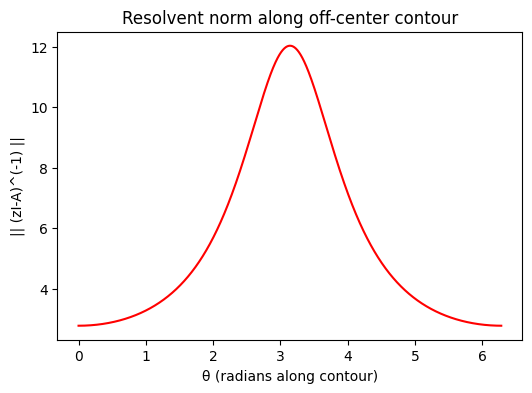

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix A
A = np.array([[0, 1],
              [0, 0]])

# Off-center contour: center slightly right of eigenvalue
center = 0.2 + 0j   # center of the circle (off origin)
radius = 0.5
N = 2000
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
z = center + radius * np.exp(1j * theta)   # gamma(t) = center + r e^{i t}
dz = 1j * radius * np.exp(1j * theta) * (2*np.pi / N)

# Compute operator-valued contour integral
integral = np.zeros((2,2), dtype=complex)
resolvent_norms = np.zeros(N)
for idx, (zi, dzi) in enumerate(zip(z, dz)):
    R = np.linalg.inv(zi*np.eye(2) - A)
    integral += R * dzi
    resolvent_norms[idx] = np.linalg.norm(R, 2)

# Riesz projection
P = integral / (2j * np.pi)
print("Numerical Riesz projection P:")
print(P)

# Plot contour and eigenvalue
plt.figure(figsize=(5,5))
plt.plot(z.real, z.imag, 'b-', label='Contour γ')
plt.plot(0, 0, 'ro', label='Eigenvalue λ=0')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Off-center contour enclosing spectrum of A')
plt.axis('equal')
plt.legend()
plt.show()

# Plot resolvent norm along contour
plt.figure(figsize=(6,4))
plt.plot(theta, resolvent_norms, 'r-')
plt.xlabel('θ (radians along contour)')
plt.ylabel('|| (zI-A)^(-1) ||')
plt.title('Resolvent norm along off-center contour')
plt.show()


In [7]:
f=lambda z:z**2
f(1+.5j)

(0.75+1j)